# The Training of the Keyword Spotting Model:

## Imports:

In [40]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import scipy.io.wavfile
from scipy.fft import fft
from tqdm import tqdm
import os
import random
import shutil
from IPython.display import Audio, display
from ipywidgets import widgets
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
import seaborn as sns
from sklearn.metrics import confusion_matrix
import librosa
import librosa.display

In [2]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


## Load the Dataset:

I am going to use Google Speech Commands Dataset for this project since it is simpler and made for the Keyword Spotting task. It is a straight forward dataset with a few activation words in English.

- Link: https://www.tensorflow.org/datasets/catalog/speech_commands?hl=pt-br

**Other Options with more complex work needed were**:

- Fluent Speech Commands Dataset: https://fluent.ai/fluent-speech-commands-a-dataset-for-spoken-language-understanding-research/

- Mozilla Common Voice: https://commonvoice.mozilla.org/en/datasets

In [3]:
(ds_train, ds_validation, ds_test), ds_info = tfds.load('speech_commands', split=['train', 'validation', 'test'], shuffle_files=True, with_info=True, as_supervised=True,)

I0000 00:00:1758223897.346941   60339 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9450 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9


In [4]:
label_names = ds_info.features['label'].names
sample_rate = ds_info.features['audio'].sample_rate

In [5]:
label_names

['down',
 'go',
 'left',
 'no',
 'off',
 'on',
 'right',
 'stop',
 'up',
 'yes',
 '_silence_',
 '_unknown_']

In [6]:
ds_train

<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.int16, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

#### Criando um Dataset Local e Selecionando os Labels Desejados:

In [7]:
if os.path.isdir('./dataset'):
    shutil.rmtree("./dataset")


base_dir = './dataset'

splits = {
    'train': ds_train,
    'validation': ds_validation,
    'test': ds_test,
}

for split_name, ds in splits.items():
    split_dir = os.path.join(base_dir, split_name)
    os.makedirs(split_dir, exist_ok=True)
    
    for label_name in label_names:
        label_dir = os.path.join(split_dir, label_name)
        os.makedirs(label_dir, exist_ok=True)
        
    counters = {label: 0 for label in label_names}

    for audio_tensor, label_tensor in tqdm(ds, desc=f"Salvando {split_name}"):
        audio_np = audio_tensor.numpy()
        label_int = label_tensor.numpy()
        label_str = label_names[label_int]
        count = counters[label_str]
        filename = f"{label_str}_{count}.wav"
        output_path = os.path.join(split_dir, label_str, filename)
        scipy.io.wavfile.write(output_path, sample_rate, audio_np)
        counters[label_str] += 1

paths = ['./dataset/train', './dataset/validation', './dataset/test']

for path in paths:
    for folder in os.listdir(path):
        if(folder == "down" or folder == "left" or folder == "up" or folder == "right" or folder == "up" or folder == "no" or folder == "yes"):
            for file in os.listdir(os.path.join(path, folder)):
                src_path = os.path.join(path, folder, file)
                dst_dir = os.path.join(path, '_unknown_')
                os.makedirs(dst_dir, exist_ok=True)
                dst_path = os.path.join(dst_dir, file)
                os.rename(src_path, dst_path)
            os.rmdir(os.path.join(path, folder))

Salvando test: 100%|██████████| 4890/4890 [00:00<00:00, 6035.87it/s]


## Exploring the Dataset:

#### Verificando Balanceamento:

In [8]:
base_dir = 'dataset'
splits = ['train', 'validation', 'test']

result_labels = []
result_counts = []

for split in splits:
    split_path = os.path.join(base_dir, split)

    class_counts = {}

    class_dirs = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]

    for class_name in class_dirs:
        class_path = os.path.join(split_path, class_name)
        num_files = len([f for f in os.listdir(class_path) if f.endswith('.wav')])
        class_counts[class_name] = num_files
        
    sorted_classes = sorted(class_counts.items(), key=lambda item: item[1], reverse=True)

    labels = [item[0] for item in sorted_classes]
    counts = [item[1] for item in sorted_classes]

    result_labels.append(labels)
    result_counts.append(counts)



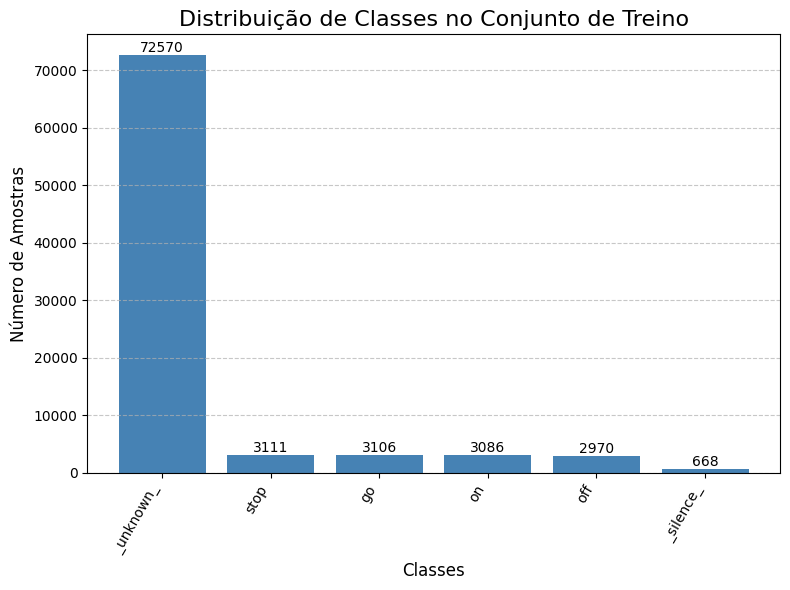

In [9]:
plt.figure(figsize=(8, 6))
    
bars = plt.bar(result_labels[0], result_counts[0], color='steelblue')

plt.title(f'Distribuição de Classes no Conjunto de Treino', fontsize=16)
plt.ylabel('Número de Amostras', fontsize=12)
plt.xlabel('Classes', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

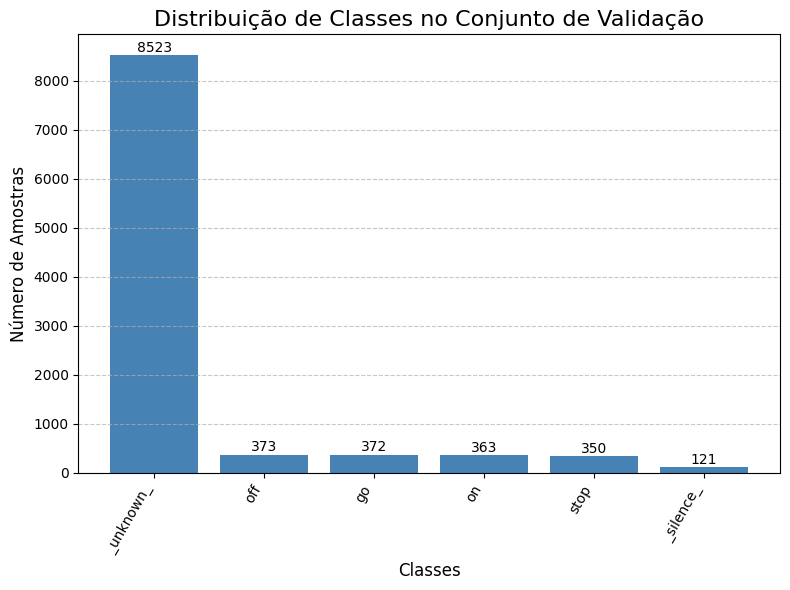

In [10]:
plt.figure(figsize=(8, 6))
    
bars = plt.bar(result_labels[1], result_counts[1], color='steelblue')

plt.title(f'Distribuição de Classes no Conjunto de Validação', fontsize=16)
plt.ylabel('Número de Amostras', fontsize=12)
plt.xlabel('Classes', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

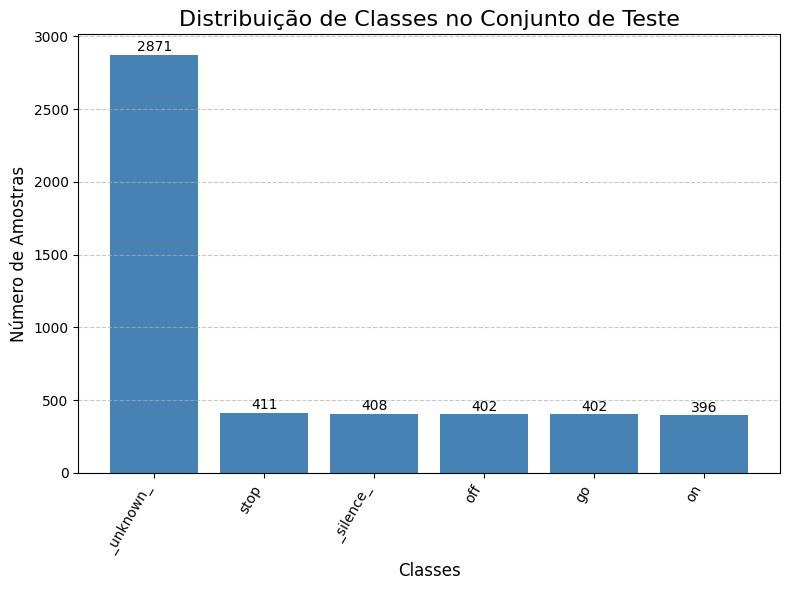

In [11]:
plt.figure(figsize=(8,6))
    
bars = plt.bar(result_labels[2], result_counts[2], color='steelblue')

plt.title(f'Distribuição de Classes no Conjunto de Teste', fontsize=16)
plt.ylabel('Número de Amostras', fontsize=12)
plt.xlabel('Classes', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

#### Balanceamento básico:

In [12]:
def del_samples(path, quant):
    all_files = os.listdir(path)
    for _ in tqdm(range(0, quant), desc=f"Deletando de {path}"):
        del_arq = random.choice(all_files)
        all_files.remove(del_arq)
        os.remove(os.path.join(path, del_arq))

In [13]:
del_samples("./dataset/train/_unknown_", 69459)

del_samples("./dataset/validation/_unknown_", 8150)

del_samples("./dataset/test/_unknown_", 2460)

Deletando de ./dataset/train/_unknown_:   0%|          | 335/69459 [00:00<00:20, 3344.55it/s]

Deletando de ./dataset/test/_unknown_: 100%|██████████| 2460/2460 [00:00<00:00, 40608.09it/s]


In [14]:
base_dir = 'dataset'
splits = ['train', 'validation', 'test']

result_labels = []
result_counts = []

for split in splits:
    split_path = os.path.join(base_dir, split)

    class_counts = {}

    class_dirs = [d for d in os.listdir(split_path) if os.path.isdir(os.path.join(split_path, d))]

    for class_name in class_dirs:
        class_path = os.path.join(split_path, class_name)
        num_files = len([f for f in os.listdir(class_path) if f.endswith('.wav')])
        class_counts[class_name] = num_files
        
    sorted_classes = sorted(class_counts.items(), key=lambda item: item[1], reverse=True)

    labels = [item[0] for item in sorted_classes]
    counts = [item[1] for item in sorted_classes]

    result_labels.append(labels)
    result_counts.append(counts)



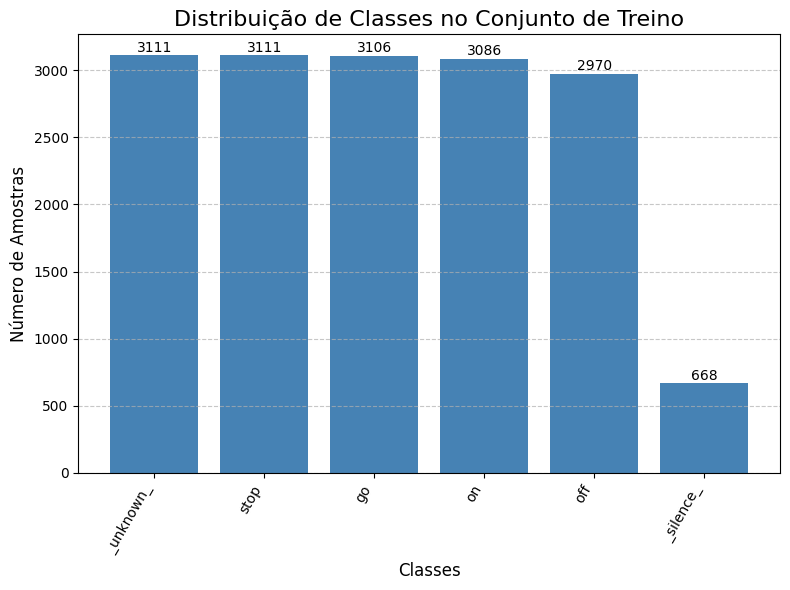

In [15]:
plt.figure(figsize=(8, 6))
    
bars = plt.bar(result_labels[0], result_counts[0], color='steelblue')

plt.title(f'Distribuição de Classes no Conjunto de Treino', fontsize=16)
plt.ylabel('Número de Amostras', fontsize=12)
plt.xlabel('Classes', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

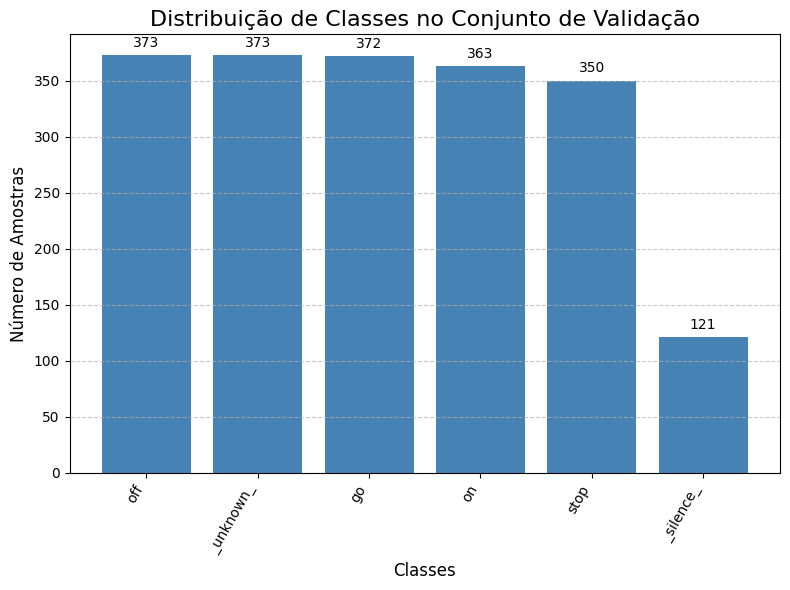

In [16]:
plt.figure(figsize=(8, 6))
    
bars = plt.bar(result_labels[1], result_counts[1], color='steelblue')

plt.title(f'Distribuição de Classes no Conjunto de Validação', fontsize=16)
plt.ylabel('Número de Amostras', fontsize=12)
plt.xlabel('Classes', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

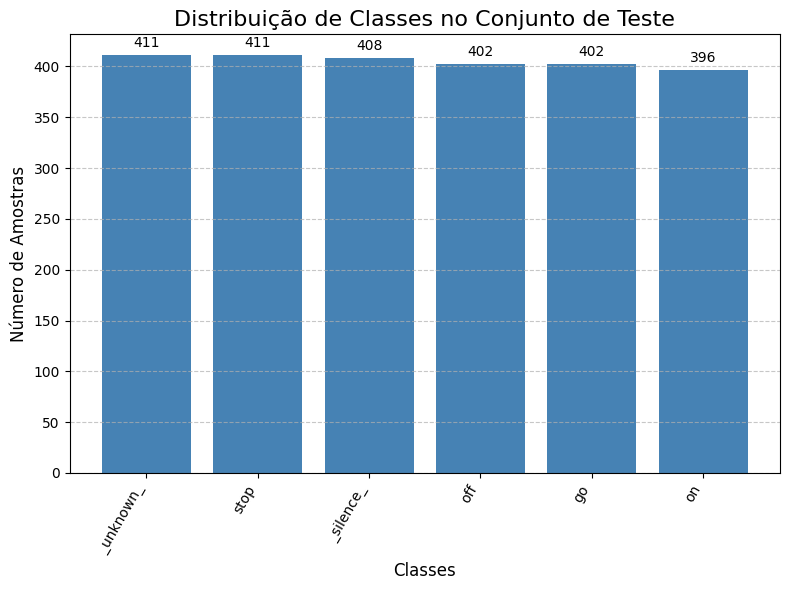

In [17]:
plt.figure(figsize=(8,6))
    
bars = plt.bar(result_labels[2], result_counts[2], color='steelblue')

plt.title(f'Distribuição de Classes no Conjunto de Teste', fontsize=16)
plt.ylabel('Número de Amostras', fontsize=12)
plt.xlabel('Classes', fontsize=12)
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 5, int(yval), va='bottom', ha='center')

plt.tight_layout()
plt.show()

#### Visualizando Amostras:

In [18]:
def plotar_exemplos_integrado(base_path: str, exemplos_por_classe: int = 5):
    try:
        classes = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
    except FileNotFoundError:
        print(f"Erro: O diretório '{base_path}' não foi encontrado.")
        return

    # Lista principal que vai conter as linhas (HBox) de cada classe
    linhas_de_widgets = []

    for class_name in classes:
        class_path = os.path.join(base_path, class_name)
        
        try:
            wav_files = [f for f in os.listdir(class_path) if f.lower().endswith('.wav')]
            if not wav_files:
                continue

            num_a_selecionar = min(exemplos_por_classe, len(wav_files))
            arquivos_selecionados = random.sample(wav_files, num_a_selecionar)

            # Lista para os "cards" (widgets.Output) desta classe
            blocos_para_linha_atual = []
            
            # Adiciona um rótulo no início da linha para identificar a classe
            label_classe = widgets.Label(
                value=f"{class_name}:",
                layout=widgets.Layout(display='flex', align_items='center', width='80px') # Layout para alinhar verticalmente
            )
            blocos_para_linha_atual.append(label_classe)

            for file_name in arquivos_selecionados:
                file_path = os.path.join(class_path, file_name)
                
                # Cria o widget de "card" individual
                card = widgets.Output(layout={'border': '1px solid black', 'padding': '5px', 'width': '180px'})
                
                with card:
                    try:
                        # Carrega o áudio
                        sr, audio = scipy.io.wavfile.read(file_path)
                        if audio.ndim > 1:
                            audio = audio[:, 0]

                        # --- Geração do Gráfico em Memória ---
                        # Cria uma figura pequena, específica para este card
                        fig, ax = plt.subplots(figsize=(3, 2), dpi=75)
                        ax.plot(audio, color='dodgerblue')
                        ax.axis('off') # Remove eixos para um visual limpo
                        plt.tight_layout()
                        
                        # Exibe a figura e a fecha para não poluir a memória
                        plt.show(fig)
                        plt.close(fig)

                        # Exibe o player de áudio
                        display(Audio(data=audio, rate=sr))
                    
                    except Exception as e:
                        print(f"Erro: {e}")

                blocos_para_linha_atual.append(card)

            # Agrupa todos os cards da classe em uma linha horizontal
            linha = widgets.HBox(blocos_para_linha_atual)
            linhas_de_widgets.append(linha)
        
        except FileNotFoundError:
            continue

    # Exibe todas as linhas empilhadas verticalmente
    display(widgets.VBox(linhas_de_widgets))

In [19]:
plotar_exemplos_integrado("dataset/train")

#### Data Augmentation:

In [ ]:
# to do

## Generating Features:

#### FFT para Rede Densa:

In [21]:
def compute_fft_for_dataset(base_path='dataset/train'):

    fft_results = []
    labels = []

    print(f"Processando arquivos em: {base_path}")

    try:
        classes = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
    except FileNotFoundError:
        print(f"Erro: O diretório '{base_path}' não foi encontrado.")
        return [], []

    for class_name in classes:
        class_path = os.path.join(base_path, class_name)
        print(f"  - Lendo classe: {class_name}")

        for file_name in os.listdir(class_path):
            if file_name.lower().endswith('.wav'):
                file_path = os.path.join(class_path, file_name)
                
                try:
                    # Carrega o áudio
                    sample_rate, audio_data = scipy.io.wavfile.read(file_path)

                    # Garante que o áudio é mono
                    if audio_data.ndim > 1:
                        audio_data = audio_data[:, 0]

                    # Calcula o FFT e a sua magnitude
                    # Apenas a primeira metade do resultado é útil (simetria)
                    N = len(audio_data)
                    fft_raw = fft(audio_data)
                    fft_magnitude = np.abs(fft_raw[:N//2])

                    # Armazena os resultados
                    fft_results.append(fft_magnitude)
                    labels.append(class_name)

                except Exception as e:
                    print(f"    - Erro ao processar o arquivo {file_name}: {e}")

    print("Processamento concluído.")
    return fft_results, labels

In [22]:
fft_data, fft_labels = compute_fft_for_dataset("./dataset/train")

Processando arquivos em: ./dataset/train
  - Lendo classe: _silence_
  - Lendo classe: _unknown_
  - Lendo classe: go
  - Lendo classe: off
  - Lendo classe: on
  - Lendo classe: stop
Processamento concluído.


In [23]:
fft_val_data, fft_val_labels = compute_fft_for_dataset("./dataset/validation")

Processando arquivos em: ./dataset/validation
  - Lendo classe: _silence_
  - Lendo classe: _unknown_
  - Lendo classe: go
  - Lendo classe: off
  - Lendo classe: on
  - Lendo classe: stop
Processamento concluído.


In [24]:
fft_data[0]

array([23054.        , 16955.50800569, 20697.34031539, ...,
       36972.52609965, 47941.35333682, 30556.52713495])

In [25]:
fft_val_data[0]

array([ 47514.        , 279455.60514458, 229747.96536756, ...,
       144737.9168063 , 241327.25020857, 114110.53991768])

Tamanho máximo e Padding:

In [26]:
tamanho_maximo = max(len(vetor) for vetor in fft_data)
tamanho_maximo

8000

In [27]:
fft_padded = tf.keras.preprocessing.sequence.pad_sequences(fft_data, maxlen=tamanho_maximo, padding='post', dtype='float32')

fft_val_padded = tf.keras.preprocessing.sequence.pad_sequences(fft_val_data, maxlen=tamanho_maximo, padding='post', dtype='float32')

In [28]:
fft_padded.shape

(16052, 8000)

In [29]:
fft_val_padded.shape

(1952, 8000)

#### Espectrograma:

In [42]:
TRAIN_PATH = 'dataset/train'

Arquivo aleatório selecionado: dataset/train/on/on_1713.wav
Shape do Espectrograma Logarítmico: (1025, 32)


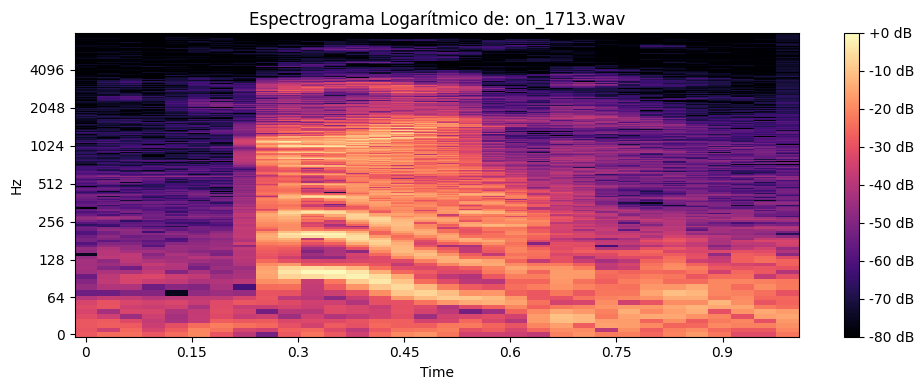

In [52]:
random_class = random.choice(os.listdir(TRAIN_PATH))
class_path = os.path.join(TRAIN_PATH, random_class)

random_wav_file = random.choice([f for f in os.listdir(class_path) if f.endswith('.wav')])
file_path = os.path.join(class_path, random_wav_file)
print(f"Arquivo aleatório selecionado: {file_path}")

audio, sr = librosa.load(file_path, sr=None)

stft_result = librosa.stft(audio)

amplitude_spectrogram = np.abs(stft_result)

log_spectrogram = librosa.amplitude_to_db(amplitude_spectrogram, ref=np.max)

print(f"Shape do Espectrograma Logarítmico: {log_spectrogram.shape}")

plt.figure(figsize=(10, 4))
librosa.display.specshow(log_spectrogram, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title(f'Espectrograma Logarítmico de: {random_wav_file}')
plt.tight_layout()
plt.show()

In [55]:
SAMPLE_RATE = 16000
DURATION = 1
SAMPLES_PER_AUDIO = SAMPLE_RATE * DURATION

PATHS = {
    'train': 'dataset/train',
    'validation': 'dataset/validation',
    'test': 'dataset/test'
}

def create_spectrograms(data_path):
    spectrograms = []
    labels = []
    
    try:
        classes = sorted(os.listdir(data_path))
    except FileNotFoundError:
        print(f"AVISO: Diretório não encontrado em '{data_path}'. Pulando.")
        return np.array([]), np.array([])
        
    for class_name in classes:
        class_path = os.path.join(data_path, class_name)
        if not os.path.isdir(class_path):
            continue
            
        print(f"  Processando classe: {class_name}")
        for file_name in os.listdir(class_path):
            if file_name.endswith('.wav'):
                file_path = os.path.join(class_path, file_name)
                
                # Carrega o áudio
                audio, sr = librosa.load(file_path, sr=SAMPLE_RATE)
                
                # Padroniza o tamanho do áudio (padding ou truncagem)
                if len(audio) < SAMPLES_PER_AUDIO:
                    audio = np.pad(audio, (0, SAMPLES_PER_AUDIO - len(audio)), mode='constant')
                else:
                    audio = audio[:SAMPLES_PER_AUDIO]
                
                # Gera o espectrograma logarítmico
                stft_result = librosa.stft(audio)
                amplitude_spectrogram = np.abs(stft_result)
                log_spectrogram = librosa.amplitude_to_db(amplitude_spectrogram, ref=np.max)
                
                spectrograms.append(log_spectrogram)
                labels.append(class_name)
                
    return np.array(spectrograms), np.array(labels)

print("Iniciando pré-processamento para o conjunto de TREINO...")
X_train, y_train = create_spectrograms(PATHS['train'])

print("\nIniciando pré-processamento para o conjunto de VALIDAÇÃO...")
X_val, y_val = create_spectrograms(PATHS['validation'])

print("\nIniciando pré-processamento para o conjunto de TESTE...")
X_test, y_test = create_spectrograms(PATHS['test'])

print("\n--- Processamento concluído ---")

# --- Preparação Final para a CNN ---

# 1. Adicionar o canal de cor (necessário para CNNs)
# Formato original: (n_amostras, n_frequencias, n_frames)
# Novo formato: (n_amostras, n_frequencias, n_frames, 1)
X_train_espectograma = X_train[..., np.newaxis]
X_val_espectograma = X_val[..., np.newaxis]
X_test_espectograma = X_test[..., np.newaxis]

# 2. Codificar os labels para o formato one-hot
label_encoder = LabelEncoder()
y_train_hot_espectograma = tf.keras.utils.to_categorical(label_encoder.fit_transform(y_train))
y_val_hot_espectograma = tf.keras.utils.to_categorical(label_encoder.transform(y_val))
y_test_hot_espectograma = tf.keras.utils.to_categorical(label_encoder.transform(y_test))

print(f"\nShape de X_train_espectograma  pronto para a CNN: {X_train.shape}")
print(f"Shape de y_train_hot_espectograma  pronto para a CNN: {y_train_hot_espectograma.shape}")
print(f"Shape de X_val_espectograma  pronto para a CNN: {X_val.shape}")
print(f"Shape de y_val_hot_espectograma  pronto para a CNN: {y_val_hot_espectograma.shape}")
print(f"Shape de X_test_espectograma  pronto para a CNN: {X_test.shape}")
print(f"Shape de y_test_hot_espectograma  pronto para a CNN: {y_test_hot_espectograma.shape}")

Iniciando pré-processamento para o conjunto de TREINO...
  Processando classe: _silence_
  Processando classe: _unknown_
  Processando classe: go
  Processando classe: off
  Processando classe: on
  Processando classe: stop

Iniciando pré-processamento para o conjunto de VALIDAÇÃO...
  Processando classe: _silence_
  Processando classe: _unknown_
  Processando classe: go
  Processando classe: off
  Processando classe: on
  Processando classe: stop

Iniciando pré-processamento para o conjunto de TESTE...
  Processando classe: _silence_
  Processando classe: _unknown_
  Processando classe: go
  Processando classe: off
  Processando classe: on
  Processando classe: stop

--- Processamento concluído ---

Shape de X_train_espectograma  pronto para a CNN: (16052, 1025, 32)
Shape de y_train_hot_espectograma  pronto para a CNN: (16052, 6)
Shape de X_val_espectograma  pronto para a CNN: (1952, 1025, 32)
Shape de y_val_hot_espectograma  pronto para a CNN: (1952, 6)
Shape de X_test_espectograma  

#### Mel Espectograma:

#### MFCC:

#### Gramian Angular Field (GAF):

#### MFE:

## Training & Testing:

#### Model 0: FFT

In [30]:
label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(fft_labels)
y_val_encoded = label_encoder.transform(fft_val_labels)

num_classes = len(label_encoder.classes_)
y_train_hot = tf.keras.utils.to_categorical(y_train_encoded, num_classes=num_classes)
y_val_hot = tf.keras.utils.to_categorical(y_val_encoded, num_classes=num_classes)

In [31]:
model_fft_CNN = tf.keras.models.Sequential([
    tf.keras.layers.Conv1D(64, 3, activation='relu', input_shape=(fft_padded.shape[1], 1)),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Conv1D(128, 3, activation='relu'),
    tf.keras.layers.MaxPooling1D(2),
    tf.keras.layers.Conv1D(256, 3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(6, activation='softmax')
])

model_fft_CNN.summary()

/home/rolds/Documents/KeyWord Spotting Wonder/Keyword-Spotting-on-Raspberry-Pi-Zero-2W/dev-env/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 7998, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 3999, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 3997, 128)      │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 1998, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 1996, 256)      │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1996, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 510976)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │   130,810,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,969,862 (499.61 MB)

 Trainable params: 130,968,582 (499.61 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [32]:
model_fft_CNN.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [33]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

In [34]:
history = model_fft_CNN.fit(x=fft_padded, y=y_train_hot, callbacks=callbacks, validation_data=(fft_val_padded, y_val_hot), epochs=100, batch_size=32, verbose=1)

Epoch 1/100


I0000 00:00:1758223932.678436   60463 service.cc:152] XLA service 0x781d34002c80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1758223932.678450   60463 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2025-09-18 16:32:12.709044: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1758223932.882286   60463 cuda_dnn.cc:529] Loaded cuDNN version 91002


  5/502 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.1661 - loss: 2.6147

I0000 00:00:1758223935.312197   60463 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


502/502 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.5784 - loss: 1.1072 - val_accuracy: 0.5656 - val_loss: 1.0520
Epoch 2/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 17s 33ms/step - accuracy: 0.6474 - loss: 0.9038 - val_accuracy: 0.5922 - val_loss: 1.0539
Epoch 3/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.6910 - loss: 0.8030 - val_accuracy: 0.6732 - val_loss: 0.8800
Epoch 4/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.7224 - loss: 0.7268 - val_accuracy: 0.6527 - val_loss: 0.9328
Epoch 5/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.7492 - loss: 0.6547 - val_accuracy: 0.7152 - val_loss: 0.7886
Epoch 6/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.7884 - loss: 0.5676 - val_accuracy: 0.6491 - val_loss: 1.7826
Epoch 7/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.8043 - loss: 0.5258 - val_accuracy: 0.6209 - val_loss: 0.9729
Epoch 8/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 17s 34ms/step - accuracy: 0.8360 - loss: 0.4400 - val_

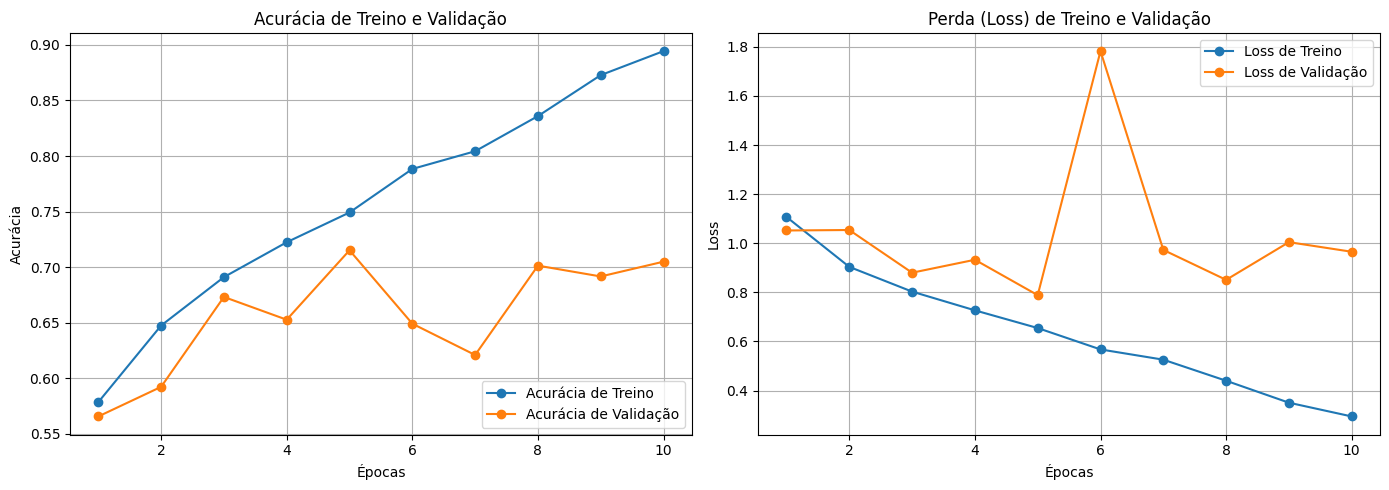

In [35]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, 'o-', label='Acurácia de Validação')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Loss de Treino')
plt.plot(epochs_range, val_loss, 'o-', label='Loss de Validação')
plt.title('Perda (Loss) de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [36]:
fft_test, fft_test_labels = compute_fft_for_dataset("./dataset/test")
fft_test_padded = tf.keras.preprocessing.sequence.pad_sequences(fft_test, maxlen=tamanho_maximo, padding='post', dtype="float32")

label_encoder = LabelEncoder()

label_encoder.fit(fft_labels + fft_val_labels + fft_test_labels)

y_test_encoded = label_encoder.transform(fft_test_labels)
y_test_hot = tf.keras.utils.to_categorical(y_test_encoded, num_classes=num_classes)

Processando arquivos em: ./dataset/test
  - Lendo classe: _silence_
  - Lendo classe: _unknown_
  - Lendo classe: go
  - Lendo classe: off
  - Lendo classe: on
  - Lendo classe: stop
Processamento concluído.


In [37]:
# Roda a predição. O resultado são as probabilidades de cada classe.
y_pred_probs = model_fft_CNN.predict(fft_test_padded)

# Converte as probabilidades para a classe com maior probabilidade (o índice)
y_pred_indices = np.argmax(y_pred_probs, axis=1)

# Converte os labels verdadeiros (one-hot) para índices também
y_true_indices = np.argmax(y_test_hot, axis=1)

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [38]:
print("--- Relatório de Classificação ---")

# Gera o relatório com precisão, recall, f1-score e suporte
# Usa os nomes das classes do label_encoder treinado anteriormente
report = classification_report(y_true_indices, y_pred_indices, target_names=label_encoder.classes_)

print(report)

--- Relatório de Classificação ---
              precision    recall  f1-score   support

   _silence_       0.97      1.00      0.98       408
   _unknown_       0.63      0.57      0.60       411
          go       0.64      0.86      0.74       402
         off       0.84      0.59      0.70       402
          on       0.72      0.75      0.74       396
        stop       0.75      0.73      0.74       411

    accuracy                           0.75      2430
   macro avg       0.76      0.75      0.75      2430
weighted avg       0.76      0.75      0.75      2430



--- Matriz de Confusão ---


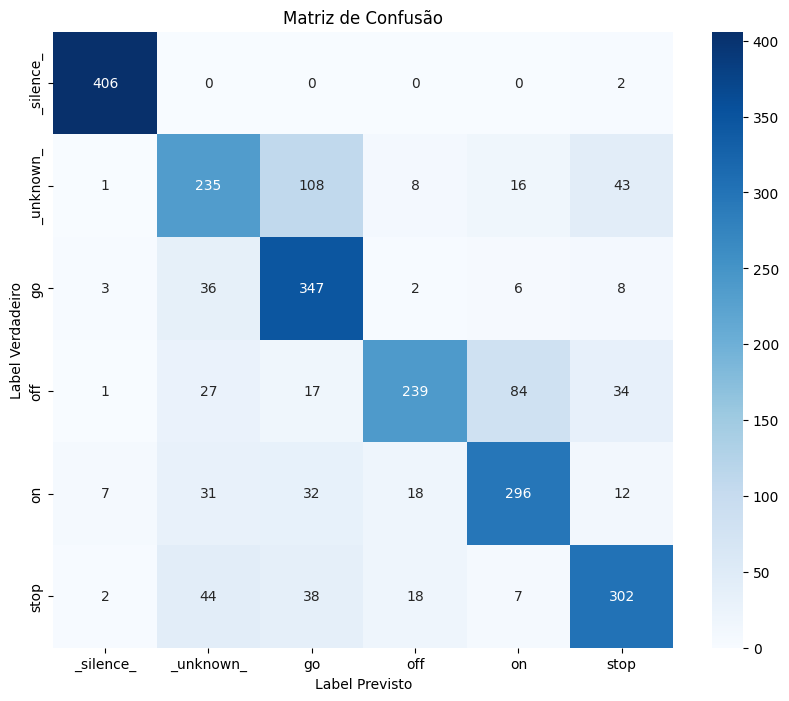

In [39]:
print("--- Matriz de Confusão ---")

# Calcula a matriz de confusão
cm = confusion_matrix(y_true_indices, y_pred_indices)

# Plota a matriz de confusão usando um heatmap do Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,          # Mostra os números dentro das células
    fmt='d',             # Formata os números como inteiros
    cmap='Blues',        # Esquema de cores
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('Matriz de Confusão')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.show()

#### Model 1: Spectograms

In [57]:
input_shape = X_train_espectograma.shape[1:]
input_shape

(1025, 32, 1)

In [68]:
model_espectograma = tf.keras.models.Sequential([
    tf.keras.layers.Input(input_shape),
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(6, activation='softmax')
])

model_espectograma.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 1025, 32, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 1025, 32, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 512, 16, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 512, 16, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 512, 16, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 256, 8, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 256, 8, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256, 8, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 128, 4, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,817,094 (129.00 MB)

 Trainable params: 33,814,854 (128.99 MB)

 Non-trainable params: 2,240 (8.75 KB)

In [69]:
model_espectograma.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [70]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
]

In [71]:
history = model_espectograma.fit(X_train_espectograma, y_train_hot_espectograma, validation_data=(X_val_espectograma, y_val_hot_espectograma),
                                callbacks = callbacks, epochs=100, batch_size=32,verbose=1)

Epoch 1/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 15s 25ms/step - accuracy: 0.5611 - loss: 1.2006 - val_accuracy: 0.6767 - val_loss: 1.1343
Epoch 2/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.7117 - loss: 0.7722 - val_accuracy: 0.7695 - val_loss: 0.6323
Epoch 3/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.7681 - loss: 0.6267 - val_accuracy: 0.7556 - val_loss: 0.6723
Epoch 4/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.7968 - loss: 0.5594 - val_accuracy: 0.6824 - val_loss: 2.2430
Epoch 5/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8113 - loss: 0.5074 - val_accuracy: 0.6409 - val_loss: 1.0883
Epoch 6/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8215 - loss: 0.4856 - val_accuracy: 0.7741 - val_loss: 0.6077
Epoch 7/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8319 - loss: 0.4553 - val_accuracy: 0.7951 - val_loss: 1.0260
Epoch 8/100
502/502 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8577 - loss: 0

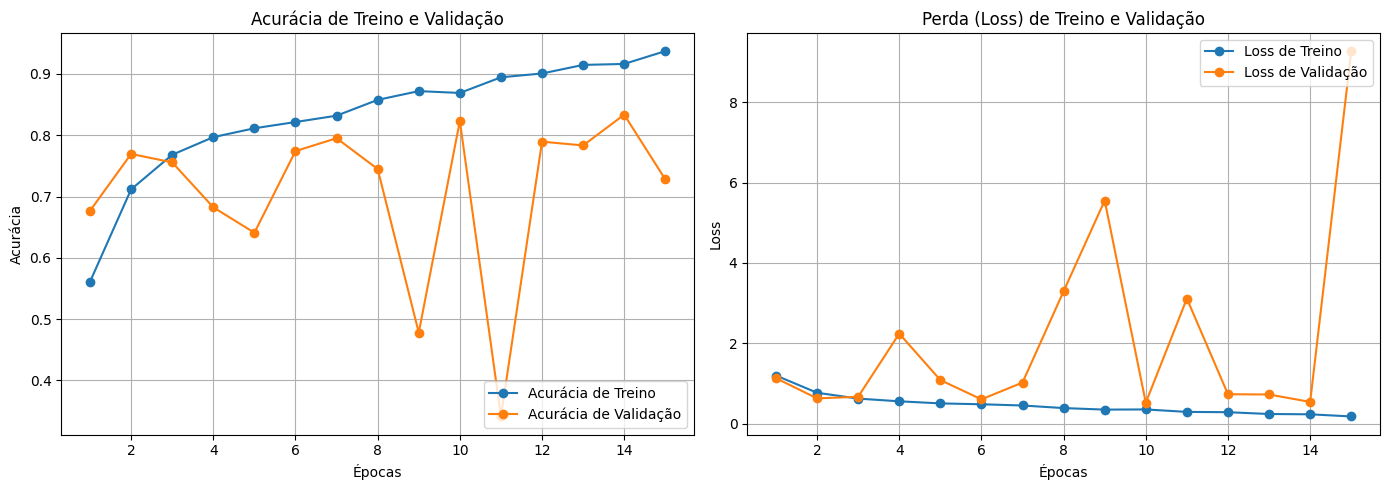

In [72]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, 'o-', label='Acurácia de Validação')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Loss de Treino')
plt.plot(epochs_range, val_loss, 'o-', label='Loss de Validação')
plt.title('Perda (Loss) de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [73]:
y_pred_probs = model_espectograma.predict(X_test_espectograma)

y_pred_indices = np.argmax(y_pred_probs, axis=1)

y_true_indices = np.argmax(y_test_hot, axis=1)

76/76 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [74]:
print("--- Relatório de Classificação ---")

# Gera o relatório com precisão, recall, f1-score e suporte
# Usa os nomes das classes do label_encoder treinado anteriormente
report = classification_report(y_true_indices, y_pred_indices, target_names=label_encoder.classes_)

print(report)

--- Relatório de Classificação ---
              precision    recall  f1-score   support

   _silence_       0.98      1.00      0.99       408
   _unknown_       0.73      0.66      0.69       411
          go       0.80      0.83      0.82       402
         off       0.78      0.90      0.84       402
          on       0.86      0.85      0.86       396
        stop       0.98      0.90      0.94       411

    accuracy                           0.86      2430
   macro avg       0.86      0.86      0.85      2430
weighted avg       0.86      0.86      0.85      2430



--- Matriz de Confusão ---


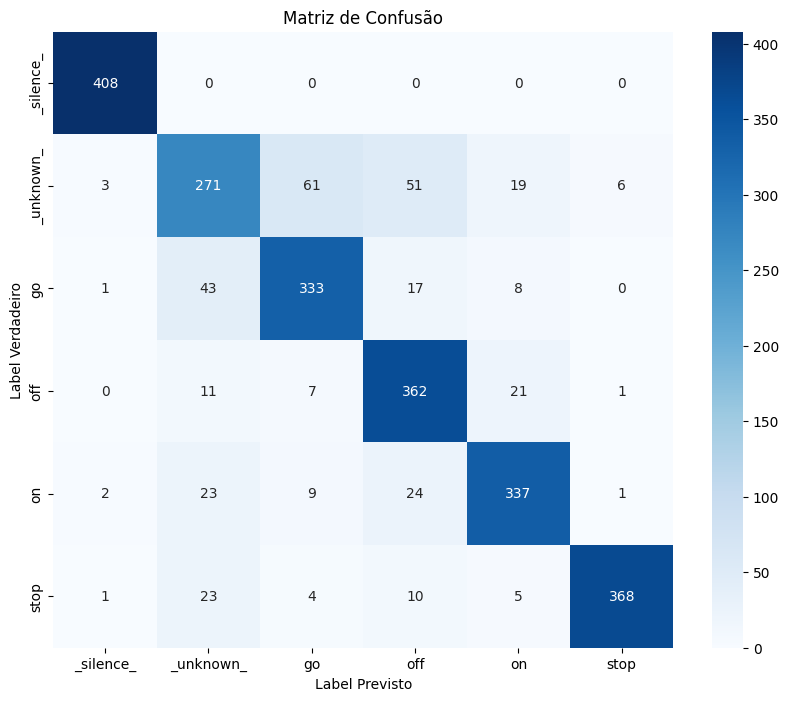

In [75]:
print("--- Matriz de Confusão ---")

# Calcula a matriz de confusão
cm = confusion_matrix(y_true_indices, y_pred_indices)

# Plota a matriz de confusão usando um heatmap do Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,          # Mostra os números dentro das células
    fmt='d',             # Formata os números como inteiros
    cmap='Blues',        # Esquema de cores
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title('Matriz de Confusão')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.show()

#### Model 2: Mel Spectograms

#### Model 3: MFCCs